In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.stats import chi2


from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True
from parismc.sampler import SamplerConfig
from parismc.sampler import Sampler

from smt.sampling_methods import LHS

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself

startup


In [2]:
#waveform class setup
waveform_class = SuperKludgeWaveform
waveform_class_kwargs = dict(inspiral_kwargs=dict(err=1e-11,),
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5))

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                      stats_for_nerds = True, use_gpu = use_gpu,
                      deriv_type='stable',
                      noise_model=get_sensitivity,
                      noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                      channels=["A","E"])

In [3]:
m1 = 1e6
m2 = 1e1
a = 0.8
e0 = 0.4
xI0 = 1.0
dist = 0.5
qS = np.pi/4
phiS = 1.0
qK = 1 
phiK = np.pi/3

Phi_phi0 = 0.9
Phi_theta0 =0.5
Phi_r0 = 0.4

dt = 10.0
T = 1.0

chi2 = 0.0

dev_A_p=0.0
dev_B_p=0.0
dev_A_e=0.0
dev_B_e=0.0

evolve_1PA = True
evolve_primary = False
evolve_2PA = False
deviation_included=True
p0=7.0

pars_list_snr = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
              chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_A_p,dev_B_p,dev_A_e,dev_B_e]

pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]


add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"devAp":dev_A_p,
"devBp":dev_B_p,"devAe":dev_A_e,"devBe":dev_B_e}

emri_kwargs = {"T":T, "dt":dt}

In [4]:
der_order = 8
Ndelta=16
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

SNR = sef.SNRcalc_SEF(*pars_list,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)
     


waveform shape:  (2, 2466201)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10.0, 0.8, 7.0, 0.4, 1.0, 0.5, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4)
SNR:  112.01108249989448


deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
Body is plunging! Expect instabilities.
Removed last 6 hours of inspiral. New evolution time: 0.7807935790079493 years
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
waveform shape:  (2, 2464041)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10.0, 0.8, 7.0, 0.4, 1.0, 0.5, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.0, True, False, False, True, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 111.82637025448633
calculating stable deltas...
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not d

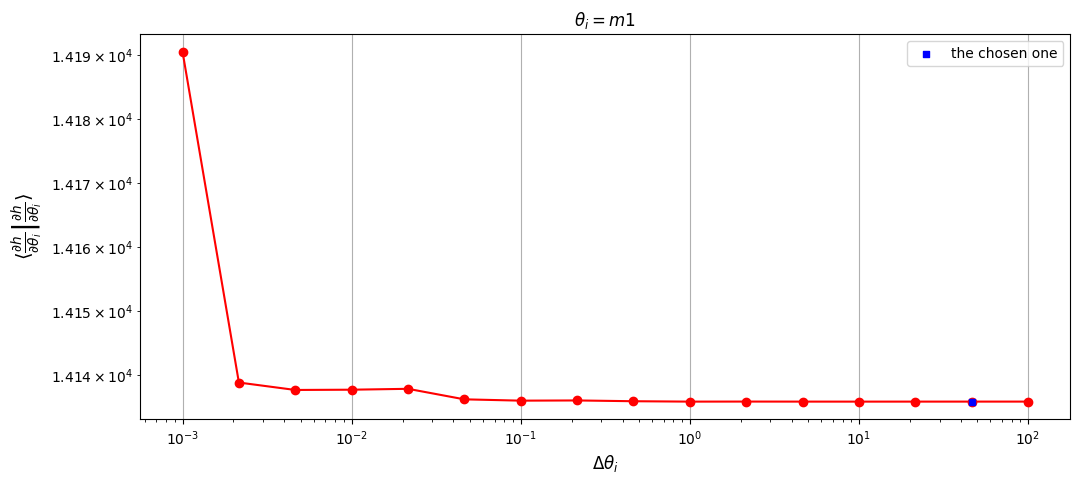

deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
Gamma_ii for m2: 11739465079090.432
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not 

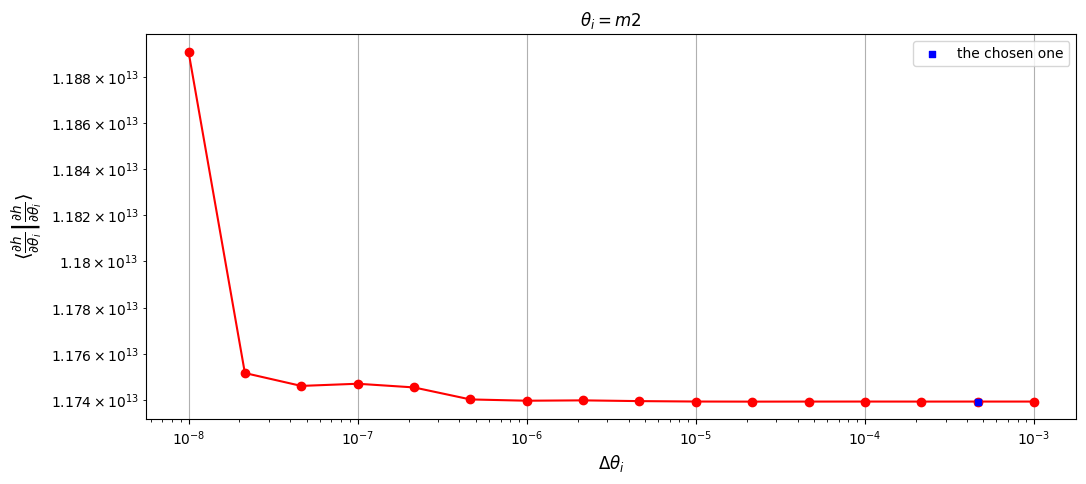

deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
Gamma_ii for a: 2365403181589517.5
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not d

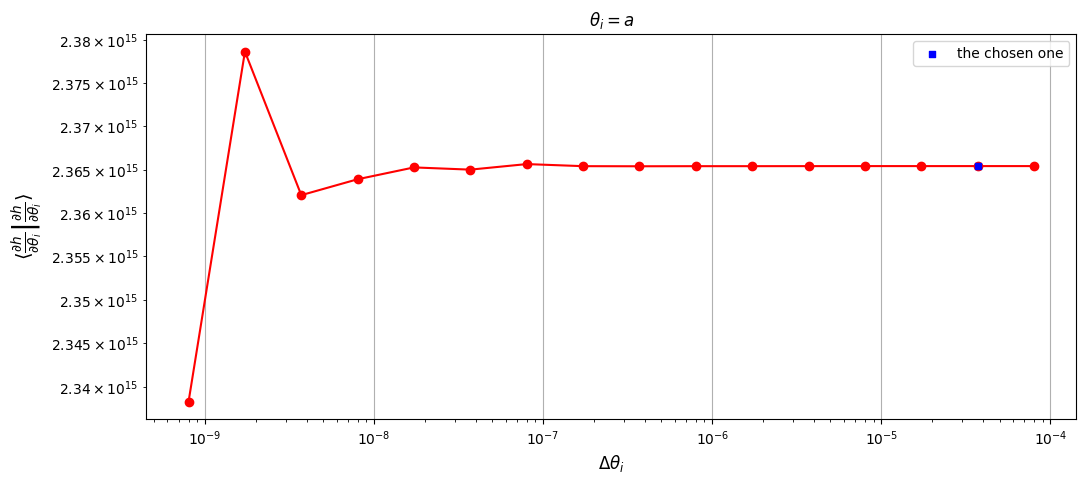

deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
plunging! t_interp:  24640400.700747635 t_traj:  24618518.109583527
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
plunging! t_interp:  24640400.700747635 t_traj:  24629383.8289317
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
plunging! t_interp:  24640400.700747635 t_traj:  24640252.83368169
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
Gamma_ii for p0: 895439773157077.0
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Defaul

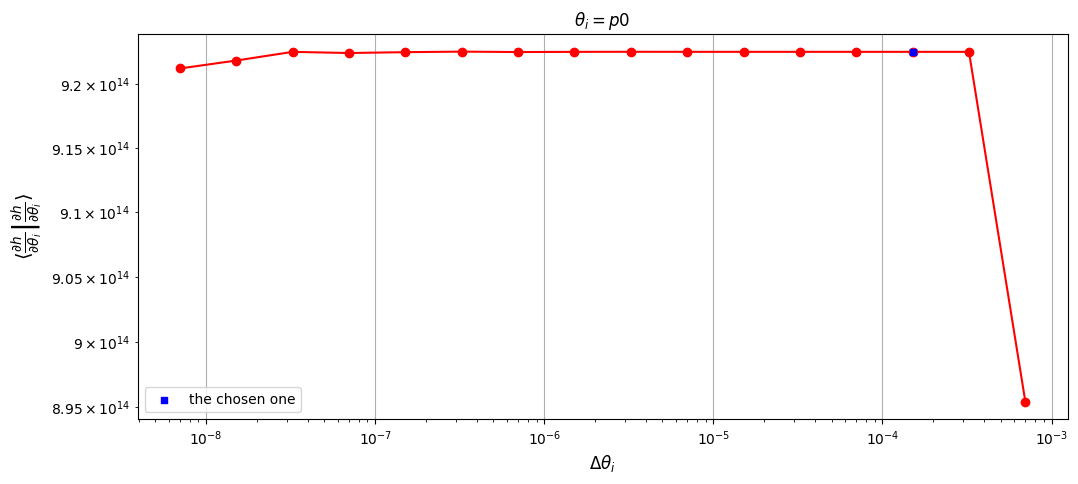

deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
Gamma_ii for e0: 1702673419234974.5
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not 

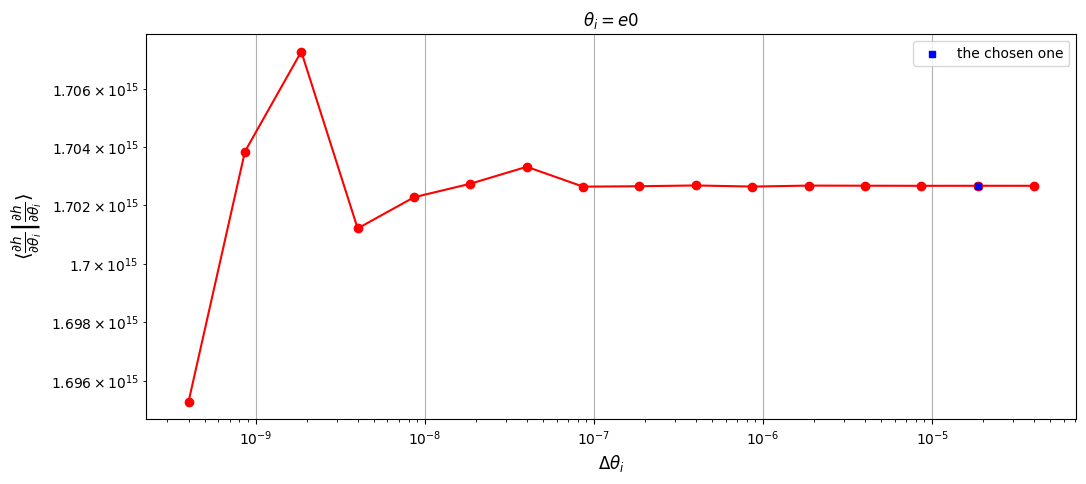

Gamma_ii for qS: 38544.400081940934
Gamma_ii for qS: 38544.40016273867
Gamma_ii for qS: 38544.40016291633
Gamma_ii for qS: 38544.40016291679
Gamma_ii for qS: 38544.40016291602
Gamma_ii for qS: 38544.40016291712
Gamma_ii for qS: 38544.40016291594
Gamma_ii for qS: 38544.40016290737
Gamma_ii for qS: 38544.4001629264
Gamma_ii for qS: 38544.40016294516
Gamma_ii for qS: 38544.40016283094
Gamma_ii for qS: 38544.40016278733
Gamma_ii for qS: 38544.400162949874
Gamma_ii for qS: 38544.400163309096
Gamma_ii for qS: 38544.4001642304
Gamma_ii for qS: 38544.40016436434
[np.float64(2.0962249673289044e-09), np.float64(4.609342272086055e-12), np.float64(1.1892397540397167e-14), np.float64(2.0009430782255953e-14), np.float64(2.8504000453967575e-14), np.float64(3.0580450818164824e-14), np.float64(2.2236895718398871e-13), np.float64(4.938176502487497e-13), np.float64(4.86644458081291e-13), np.float64(2.963283437929691e-12), np.float64(1.1314766802758737e-12), np.float64(4.217081921464201e-12), np.float64(9

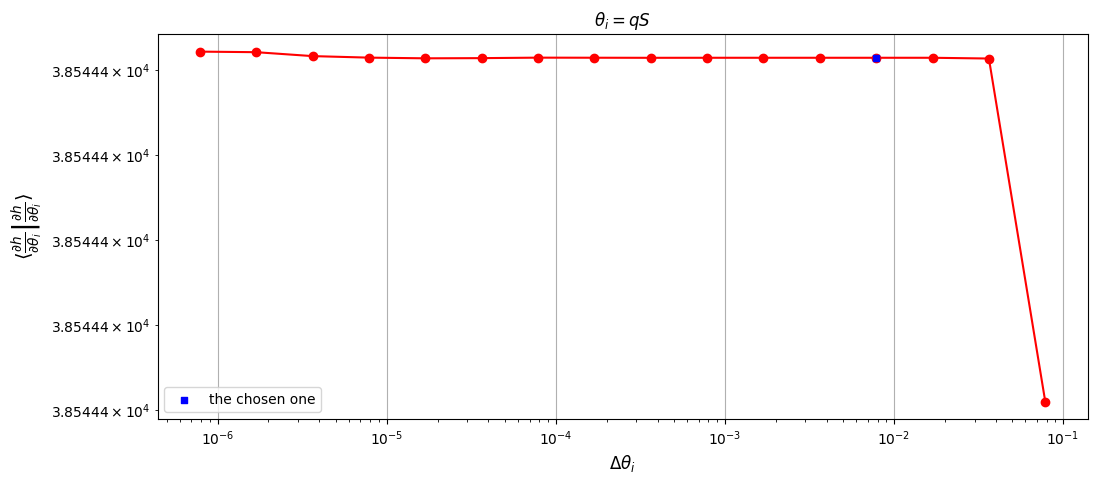

Gamma_ii for phiS: 740982.8141631276
Gamma_ii for phiS: 740982.814134608
Gamma_ii for phiS: 740982.8141345453
Gamma_ii for phiS: 740982.814134545
Gamma_ii for phiS: 740982.814134545
Gamma_ii for phiS: 740982.814134545
Gamma_ii for phiS: 740982.814134545
Gamma_ii for phiS: 740982.814134545
Gamma_ii for phiS: 740982.814134545
Gamma_ii for phiS: 740982.8141345453
Gamma_ii for phiS: 740982.8141345464
Gamma_ii for phiS: 740982.8141345446
Gamma_ii for phiS: 740982.8141345419
Gamma_ii for phiS: 740982.8141345383
Gamma_ii for phiS: 740982.8141344866
Gamma_ii for phiS: 740982.8141345346
[np.float64(3.848880353560186e-11), np.float64(8.468193494879668e-14), np.float64(3.142186825558319e-16), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(3.142186825558318e-16), np.float64(1.5710934127791568e-15), np.float64(2.513749460446657e-15), np.float64(3.613514849392083e-15), np.float64(4.87038957961544e-15), np.float64(6.97565475274002e-14), np.float64(6.47

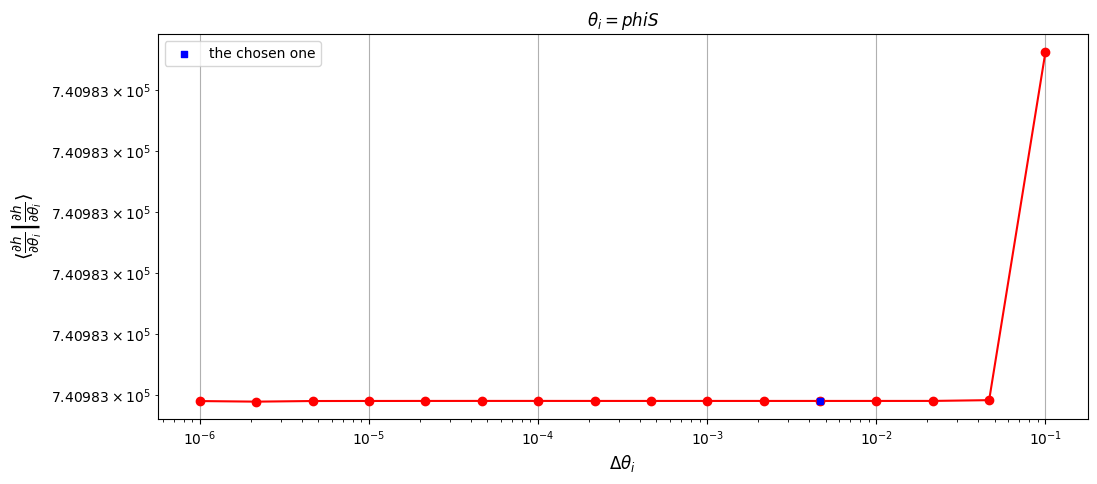

deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
Gamma_ii for devAp: 1019291345279145.0
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P n

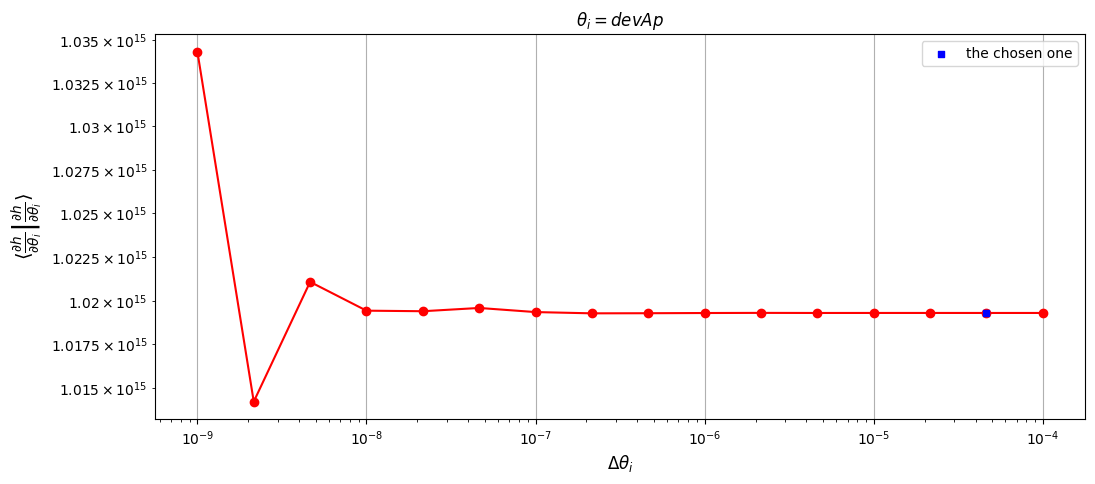

deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
Gamma_ii for devBp: 6592183382048.554
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P no

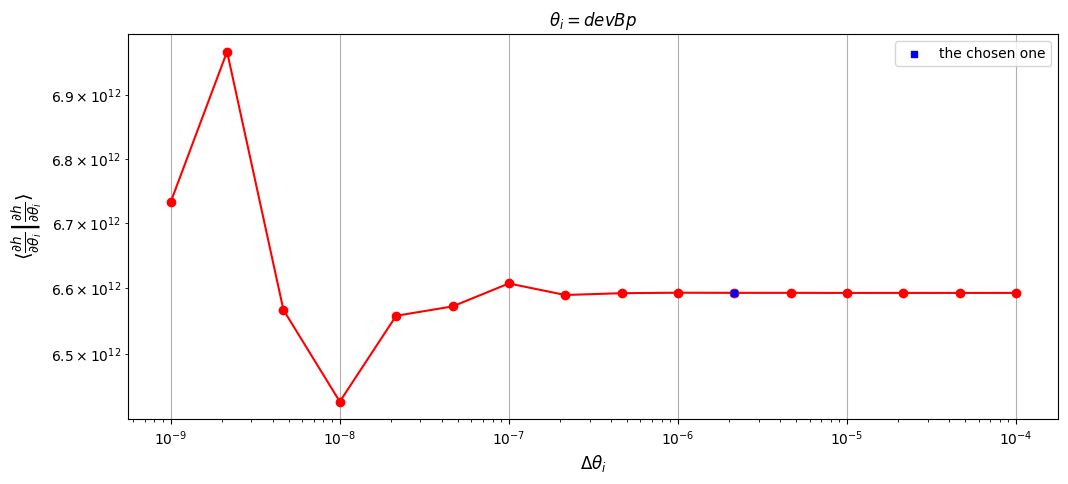

deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
Gamma_ii for devAe: 4.979307480637847
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P no

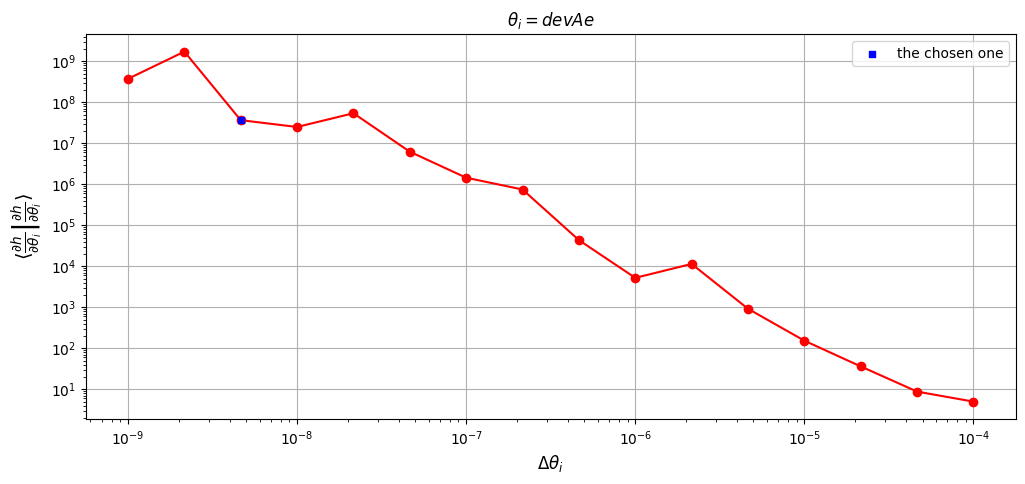

deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
Gamma_ii for devBe: 4.080156902486241
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P no

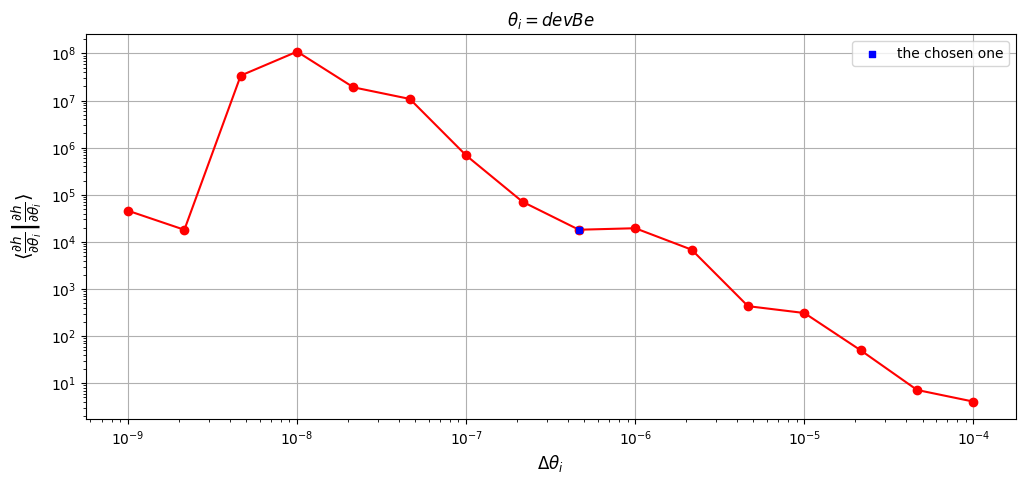

stable deltas: {'m1': 46.4158883361278, 'm2': 0.00046415888336127773, 'a': 3.713271066890227e-05, 'p0': 0.00015081042830223195, 'e0': 1.8566355334451135e-05, 'qS': 0.007853981633974485, 'phiS': 0.004641588833612782, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'devAp': 4.641588833612782e-05, 'devBp': 2.1544346900318865e-06, 'devAe': 4.641588833612792e-09, 'devBe': 4.641588833612782e-07}
Time taken to compute stable deltas is 103.21403336524963 seconds
calculating Fisher matrix...
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_P not defined. Default to Zero
deviation 0_P not defined. Default to Zero
deviation 2_

In [5]:
param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','devAp','devBp','devAe','devBe']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}


Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,return_derivatives=True
            )


In [6]:
from stableemrifisher.utils import fishinv
J = np.eye(len(Fisher))
J[0,0] = m1
Fisher_lnM = J.T @ Fisher @ J
Fisher_lnM_inv = np.linalg.inv(Fisher_lnM)
Fisher_inv = J.T @ Fisher_lnM_inv @ J
pd.DataFrame(np.matmul(Fisher_lnM,Fisher_lnM_inv))

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

In [ ]:
print(np.linalg.cond(Fisher_lnM))
np.sum(np.matmul(Fisher_lnM,Fisher_lnM_inv))


In [ ]:
from stableemrifisher.plot import CovEllipsePlot
# pars_list = [m1, m2, p0, e0, dist,qS,phiS,Phi_phi0,Phi_r0,chi2]
# param_names = ['m1','m2','p0','e0','dist','qS','phiS','Phi_phi0','Phi_r0','chi2']
pars_list = [np.log(m1), m2, p0, e0, dist,qS,phiS,Phi_phi0,Phi_r0,dev_0_p,dev_0_e]
param_names = ["ln (m1)",'m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0',"dev_0_p","dev_0_e"]
wave_params = {}
for i in range(len(pars_list)):
    wave_params[param_names[i]] = pars_list[i]
    
covariance = Fisher_lnM_inv

ellipse_kwargs = dict(facecolor='None', edgecolor='b', lw=2)
line_kwargs = dict(lw=2, color='b')

fig, axs = plt.subplots(len(covariance),len(covariance), figsize=(20,20))
fig, axs = CovEllipsePlot(covariance, wave_params=wave_params, param_names=param_names, fig=fig, axs=axs, ellipse_kwargs=ellipse_kwargs, line_kwargs=line_kwargs)